# Fase 4 — Métricas avanzadas y comparación

Módulos 8–11: xG por tramos de partido, pizza charts, radar clásico y
beeswarm charts.

**Reescrito con datos reales (2026-08-25)** — esta versión ya no usa datos
sintéticos. Combina dos fuentes reales:

- **xG por tramos de partido**: eventos reales de StatsBomb (el partido de
  ejemplo cacheado en `01_scraping_fotmob_statsbomb.ipynb`), porque esto
  necesita datos evento a evento con minuto y xG por tiro — algo que FBref no
  entrega en sus tablas de temporada.
- **Pizza chart / beeswarm**: dataset real de FBref, Big 5 ligas, 2024-25
  (`data/raw/fbref_big5_player_standard_2025.csv` + las dos columnas
  defensivas reales de `fbref_big5_player_defense_partial_2025.csv`) — el
  mismo dataset que `06_scouting_percentiles_similaridad.ipynb`. Se dejaron
  fuera `xg_90`, `xa_90`, `pases_completados_pct` y `regates_exitosos_90`
  porque nunca conseguimos esas columnas reales de FBref (ver conclusión en
  el plan de trabajo, Fase 7).

In [11]:
import pandas as pd

df = pd.read_csv("../data/raw/fbref_big5_player_standard_2025.csv")
defensa = pd.read_csv("../data/raw/fbref_big5_player_defense_partial_2025.csv")

df = df.merge(
    defensa[["player", "team", "tackles_won", "interceptions"]],
    on=["player", "team"], how="left",
)

# Filtramos a jugadores con minutos suficientes (ver 07 para la explicación
# de por qué esto importa para no distorsionar percentiles).
df = df[df["minutes_90s"] >= 10].copy()

df["tackles_won_per90"] = df["tackles_won"] / df["minutes_90s"]
df["interceptions_per90"] = df["interceptions"] / df["minutes_90s"]
df["posicion_principal"] = df["position"].str.split(",").str[0]

metricas = [
    "goals_per90", "assists_per90", "goals_assists_per90", "goals_pens_per90",
    "tackles_won_per90", "interceptions_per90",
]

print(f"{len(df)} jugadores regulares")
df[["player", "team", "posicion_principal"] + metricas].head()

1573 jugadores regulares


,player,team,posicion_principal,goals_per90,assists_per90,goals_assists_per90,goals_pens_per90,tackles_won_per90,interceptions_per90
5,Yunis Abdelhamid,Saint-Étienne,DF,0.00,0.00,0.00,0.00,0.956522,1.217391
6,Himad Abdelli,Angers,MF,0.19,0.03,0.22,0.10,1.012658,0.854430
8,Ali Abdi,Nice,MF,0.32,0.13,0.45,0.32,1.741935,1.290323
12,Matthis Abline,Nantes,FW,0.29,0.07,0.36,0.26,0.129870,0.194805
13,Abner,Lyon,DF,0.08,0.08,0.17,0.08,1.652893,0.495868


## xG por tramos de partido

Usamos los eventos reales de StatsBomb cacheados en
`01_scraping_fotmob_statsbomb.ipynb` (Brasil vs. Bélgica, Mundial 2018).
Agrupamos los tiros por rango de minuto y sumamos el xG de cada tramo.

(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, '(0, 15]'),
  Text(1, 0, '(15, 30]'),
  Text(2, 0, '(30, 45]'),
  Text(3, 0, '(45, 60]'),
  Text(4, 0, '(60, 75]'),
  Text(5, 0, '(75, 90]'),
  Text(6, 0, '(90, 120]')])

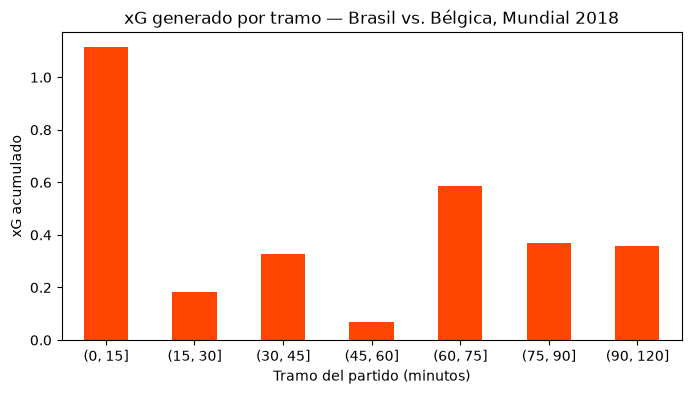

In [12]:
import matplotlib.pyplot as plt

events = pd.read_pickle("../data/processed/events_ejemplo.pkl")
shots = events[events["type"] == "Shot"].copy()

bins = [0, 15, 30, 45, 60, 75, 90, 120]
shots["tramo"] = pd.cut(shots["minute"], bins=bins)
xg_por_tramo = shots.groupby("tramo", observed=True)["shot_statsbomb_xg"].sum()

fig, ax = plt.subplots(figsize=(8, 4))
xg_por_tramo.plot(kind="bar", ax=ax, color="orangered")
ax.set_ylabel("xG acumulado")
ax.set_xlabel("Tramo del partido (minutos)")
ax.set_title("xG generado por tramo — Brasil vs. Bélgica, Mundial 2018")
plt.xticks(rotation=0)

## Radar / pizza chart

Un pizza chart es un radar donde cada eje se colorea según el percentil del
jugador respecto a un grupo de comparación (su posición, su liga, etc.).

Text(0.5, 1.0, 'Perfil de percentiles — Kylian Mbappé (vs. FW de las 5 grandes ligas)')

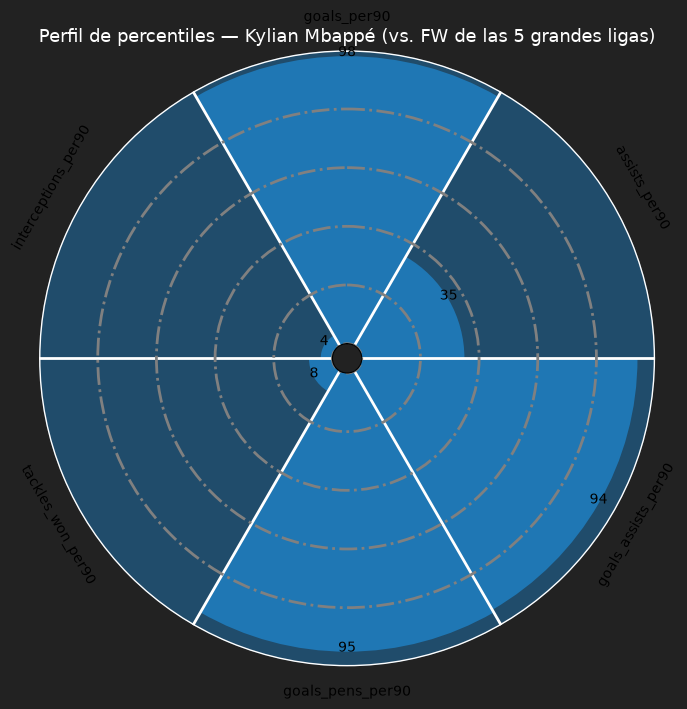

In [13]:
from mplsoccer import PyPizza

percentiles = df.groupby("posicion_principal")[metricas].rank(pct=True) * 100
percentiles = percentiles.round(0).astype(int)
percentiles.insert(0, "player", df["player"])
percentiles.insert(1, "posicion_principal", df["posicion_principal"])

jugador_foco = "Kylian Mbappé"  # cambia el nombre para ver a otro jugador
fila = percentiles[percentiles["player"] == jugador_foco].iloc[0]

baker = PyPizza(
    params=metricas,
    background_color="#222222",
    straight_line_color="#FFFFFF",
    last_circle_color="#FFFFFF",
    other_circle_ls="-.",
)
fig, ax = baker.make_pizza(
    fila[metricas].tolist(),
    figsize=(8, 8),
    color_blank_space="same",
    param_location=110,
)
ax.set_title(
    f"Perfil de percentiles — {jugador_foco} (vs. {fila['posicion_principal']} de las 5 grandes ligas)",
    color="white", fontsize=13,
)

## Beeswarm chart

Compara a un jugador (o a toda la plantilla) contra la distribución de la
competición en una métrica concreta. `seaborn.swarmplot` es la vía más rápida.

Text(0.5, 1.0, 'Goles/90 — delanteros de las 5 grandes ligas (rojo = Kylian Mbappé)')

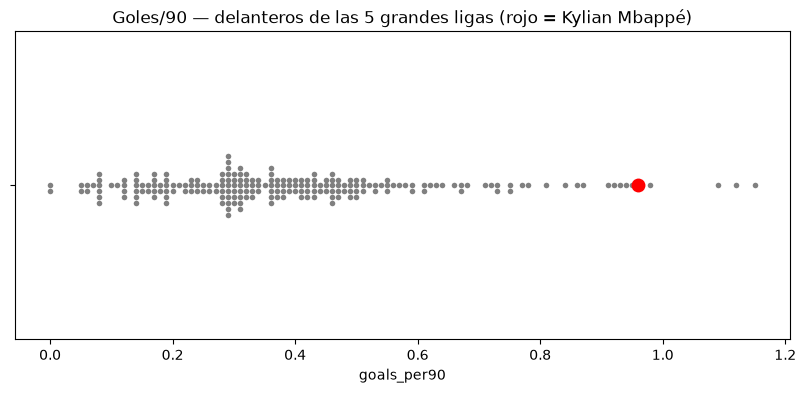

In [14]:
import seaborn as sns

delanteros = df[df["posicion_principal"] == "FW"]

fig, ax = plt.subplots(figsize=(10, 4))
sns.swarmplot(x=delanteros["goals_per90"], ax=ax, color="grey", size=4)

destacado = delanteros[delanteros["player"] == jugador_foco]
sns.swarmplot(x=destacado["goals_per90"], ax=ax, color="red", size=10)
ax.set_title(f"Goles/90 — delanteros de las 5 grandes ligas (rojo = {jugador_foco})")

## Pendiente

- Igual que en `06_scouting_percentiles_similaridad.ipynb`: el perfil de
  percentiles sigue siendo mayormente ofensivo porque FBref no entrega al
  público las columnas detalladas de passing/defense (confirmado, no vale la
  pena reintentarlo).
- El xG por tramos usa un solo partido de ejemplo — para un análisis real de
  varios partidos, repetir la descarga de `sb.events(match_id)` por cada
  partido y concatenar antes de agrupar por tramo.

Siguiente notebook: `05_reporte_automatizado_partido.ipynb`.